In [2]:
from tool_server.utils.utils import *
from tool_server.utils.prompts import tool_planning_model_prompt_one_tool_call
from tqdm import tqdm
import json, os

input_data = "/mnt/petrelfs/songmingyang/code/reasoning/data_construction/PixelReasoner/data/pixelreasonersft_groundingcrop_formatted.jsonl"


input_data = process_jsonl(input_data)
output_path = "/mnt/petrelfs/songmingyang/code/reasoning/data_construction/PixelReasoner/data/supply_grounding_data/pixelreasonersft_groundingcrop_sground.jsonl"

pixel_reasoner_basedir = "/mnt/petrelfs/songmingyang/songmingyang/data/vl_reasoning/tool_dataset/PixelReasoner-SFT-Data"

tool_name_list = ["OCR","HighlightBox","GroundingDINO","DrawLine","LanguageModel","SegmentRegionAroundPoint","GetSubplotInfo","Crop","Point","DrawShape","MaskBox","GetBarInfo"]


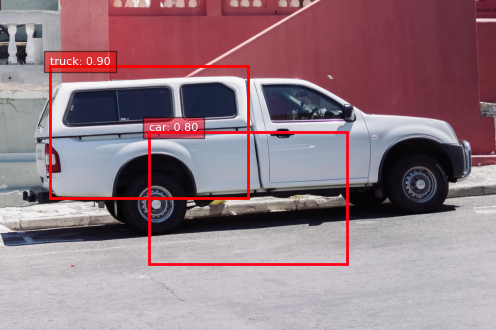

In [3]:
import numpy as np
import matplotlib
from PIL import Image
from io import BytesIO

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from copy import deepcopy

def annotate_image(image_np, boxes, logits, phrases):
    """在图像上绘制边界框和标签"""
    # 设置matplotlib使用非交互模式
    matplotlib.use('Agg')
    
    # 创建一个新的图形和轴
    fig, ax = plt.subplots(1)
    ax.imshow(image_np)
    
    # 获取图像尺寸
    h, w, _ = image_np.shape
    
    # 为不同类别设置不同颜色
    unique_phrases = list(set(phrases))
    colors = plt.cm.hsv(np.linspace(0, 1, len(unique_phrases) if len(unique_phrases) > 0 else 1))
    color_map = {phrase: colors[i % len(colors)] for i, phrase in enumerate(unique_phrases)}
    
    # 绘制每个检测框
    for i, (box, logit, phrase) in enumerate(zip(boxes, logits, phrases)):
        # 获取边界框坐标
        x_min, y_min, x_max, y_max = box
        # 将归一化坐标转换为像素坐标
        x_min_px, y_min_px = int(x_min * w), int(y_min * h)
        x_max_px, y_max_px = int(x_max * w), int(y_max * h)
        
        # 计算宽度和高度
        width = x_max_px - x_min_px
        height = y_max_px - y_min_px
        
        # 获取当前类别的颜色
        color = color_map.get(phrase, 'red')
        
        # 创建一个矩形
        rect = patches.Rectangle(
            (x_min_px, y_min_px), width, height, 
            linewidth=2, edgecolor=color, facecolor='none'
        )
        
        # 添加矩形到轴
        ax.add_patch(rect)
        
        # 添加标签文本
        confidence = f"{logit:.2f}"
        label = f"{phrase}: {confidence}"
        plt.text(
            x_min_px, y_min_px - 5, label, 
            bbox=dict(facecolor=color, alpha=0.5),
            fontsize=8, color='white'
        )
    
    # 移除轴标签
    plt.axis('off')
    
    # 将图形保存到内存缓冲区
    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0, dpi=100)
    plt.close(fig)
    buf.seek(0)
    
    # 从缓冲区加载图像
    annotated_image = Image.open(buf).convert('RGB')
    return annotated_image

image_path = "/mnt/petrelfs/songmingyang/code/reasoning/tool-agent/tool_server/tool_workers/online_workers/test_cases/worker_tests/input_cases/truck.jpg"
image = Image.open(image_path).convert('RGB')
arr = np.array(image)
boxes = [[0.1, 0.2, 0.5, 0.6], [0.3, 0.4, 0.7, 0.8]]
phrases = ["truck", "car"]
logits = [0.9, 0.8]
annotated_image = annotate_image(arr, boxes, logits, phrases)
annotated_image

In [4]:
def supply_groundingdino_to_one_conv(conv, original_picture_addr, image_save_path):
    original_picture = Image.open(original_picture_addr).convert('RGB')
    original_picture_arr =  np.array(original_picture)
    if "content" not in conv:
        return
    contents = conv["content"]
    new_conv = deepcopy(conv)
    
    for content in contents:
        try:
            if "text" in content:
                content_text = content["text"]
                tool_response = json.loads(content_text)
                detections = tool_response["detections"]
                labels = []
                boxes = []
                logits = []
                for detection in detections:
                    boxes = detection["bbox"]
                    new_box = [boxes["x_min"], boxes["y_min"], boxes["x_max"], boxes["y_max"]]
                    boxes.append(new_box)
                    labels.append(detection["label"])
                    logits.append(detection["confidence"])
                new_image = annotate_image(original_picture_arr, boxes, logits, labels)
                new_image.save(image_save_path)
                new_conv = dict(role="user",content=[dict(type="text",text=tool_response),dict(type="image",image=image_save_path)])
                return new_conv
        except:
            return None
    

In [14]:
def supply_with_gd(
    input_data, 
    image_dir_path="/mnt/petrelfs/songmingyang/songmingyang/data/vl_reasoning/tool_dataset/PixelReasoner-SFT-Data/images",
    output_dir_path = "/mnt/petrelfs/songmingyang/songmingyang/data/vl_reasoning/tool_dataset/PixelReasoner-SFT-Data/gd_images"
):
    
    for item in tqdm(input_data):
        conversations = item["response_messages"]
        origin_qid = item["origin_qid"]
        qid = item["qid"]
        new_conversations = []
        next_round_operate = None
        terminate = False
        for conv in conversations:
            # print(f"Processing conversation: {conv}")
            if "content" not in conv or "role" not in conv:
                terminate = True
                break
            contents = conv["content"]
            
            if next_round_operate:
                new_conv = supply_groundingdino_to_one_conv(
                    conv, 
                    original_picture_addr=next_round_operate["original_picture_addr"],
                    image_save_path=next_round_operate["image_save_path"]
                )
                if new_conv is None:
                    terminate = True
                    break
                else:
                    new_conversations.append(new_conv)
                    next_round_operate = None
                    continue
            else:
                new_conversations.append(conv)
                for content in contents:
                    if isinstance(content, str) or "text" in content:
                        if isinstance(content, str):
                            content_text = content
                        elif "text" in content:
                            content_text = content["text"]
                            if "<tool_call>" in content_text:
                                tool_json = content_text.split("<tool_call>")[-1].split("</tool_call>")[0]
                                
                                try:
                                    tool_content = json.loads(tool_json)
                                    tool_name = tool_content["name"]
                                    if tool_name == "GroundingDINO":
                                        next_round_operate = {
                                            "original_picture_addr" : f"{image_dir_path}/{origin_qid}-0.jpg",
                                            "image_save_path": f"{output_dir_path}/{origin_qid}-gd.jpg",
                                        }
                                    assert tool_name in tool_name_list, f"Tool name {tool_name} not in predefined list."
                                    
                                except:
                                    tool_name = "invalid"
                                    terminate = True
                                    break
                        
               
            if terminate:
                break
            
        if terminate:
            continue
        item["conversations"] = new_conversations
    return input_data
        
        
            

In [15]:
adjusted_data = supply_with_gd(input_data)

100%|██████████| 400/400 [00:10<00:00, 36.68it/s]


In [16]:
write_jsonl(adjusted_data, output_path)
len(adjusted_data)


400

In [ ]:
image_dir_path = "/mnt/petrelfs/songmingyang/songmingyang/data/vl_reasoning/tool_dataset/PixelReasoner-SFT-Data"
sft_data = []
tool_statistic_dict = {}
average_tool_call_list = []
conv_unqualify = 0

for item in tqdm(input_data):
    conversations = item["response_messages"]
    origin_qid = item["origin_qid"]
    qid = item["qid"]
    
    new_conversations = [{"from":"system","value":tool_planning_model_prompt_one_tool_call}]
    image_cnt = 0
    image_indexes = []
    terminate = False
    current_tool_call_num = 0
    # print(f"Processing conversation: {conversations}")
    if not isinstance(conversations, list):
        conversations = [conversations]
    if len(conversations) <= 2:
        continue
    
    for conv in conversations:
        # print(f"Processing conversation: {conv}")
        if "content" not in conv or "role" not in conv:
            terminate = True
            break
        
        new_role = "gpt" if conv["role"] == "assistant" else "human"
        contents = conv["content"]
        
        new_value = ""
        for content in contents:
            # print(f"Processing content: {content}")
            if isinstance(content, str):
                new_value += content
            elif "image" in content or "image_url" in content:
                new_value += f"\n<image>\n"
                image_cnt += 1
                image_content = "img_1"
                if content.get("image_url"):
                    if isinstance(content["image_url"], str):
                        image_content = content["image_url"]
                    else:
                        image_content = content["image_url"].get("url", "img_1")
                else:
                    image_content = content.get("image", "img_1")
                
                image_index = int(image_content.split("_")[-1])-1
                image_index = 1 if image_index > 1 else image_index
                image_indexes.append(image_index)
            elif "text" in content:
                new_value += f"{content['text']}"
                text_content = content['text']
                if "<tool_call>" in text_content:
                    tool_json = text_content.split("<tool_call>")[-1].split("</tool_call>")[0]
                    
                    try:
                        tool_content = json.loads(tool_json)
                        tool_name = tool_content["name"]
                        
                        assert tool_name in tool_name_list, f"Tool name {tool_name} not in predefined list."
                        current_tool_call_num += 1
                        tool_statistic_dict[tool_name] = tool_statistic_dict.get(tool_name, 0) + 1
                        
                    except:
                        conv_unqualify += 1
                        tool_name = "invalid"
                        qualify = 0
                        terminate = True
                        break
            elif "tool_code" in content or "tool_call" in content or "tool_response" in content or "tool_response_from" in content:
                terminate = True
                break
            else:
                raise ValueError(f"Unknown content type: {content['type']}")
        if terminate:
            break
        new_conversations.append({"from": new_role, "value": new_value})
    if terminate:
        continue
    average_tool_call_list.append(current_tool_call_num)
    
    new_jpg_files = [jpg_files[i] for i in image_indexes]
    assert image_cnt == len(new_jpg_files), f"Image count mismatch for {origin_qid}: {image_cnt} vs {len(jpg_files)}"
    new_item = {
        "qid": qid,
        "conversations": new_conversations,
        "images": new_jpg_files,
    }
    sft_data.append(new_item)
    
average_tool_call = sum(average_tool_call_list) / len(average_tool_call_list)
    

100%|██████████| 400/400 [00:00<00:00, 430.28it/s]


In [48]:
# len(sft_data),conv_unqualify
tool_statistic_dict, average_tool_call

({'HighlightBox': 360, 'GroundingDINO': 18}, 0.9842105263157894)

In [49]:
write_json_file(sft_data, output_path)
len(sft_data)

380

In [54]:
sft_data2 = []
tool_statistic_dict = {}
average_tool_call_list = []
conv_unqualify = 0
for item in tqdm(input_data2):
    conversations = item["response_messages"]
    origin_qid = item["origin_qid"]
    qid = item["qid"]
    current_dir = os.path.join(refocus_data_dir, origin_qid)
    
    jpg_files = [f for f in os.listdir(current_dir) 
             if (f.endswith(".jpg") or f.endswith(".png")) and os.path.isfile(os.path.join(current_dir, f))]
    qid_file_name = f"{origin_qid}.jpg"
    jpg_files.sort(key=lambda x: 0 if x == qid_file_name else 1)
    jpg_files = [os.path.join(current_dir, f) for f in jpg_files]
    
    new_conversations = [{"from":"system","value":tool_planning_model_prompt_one_tool_call}]
    image_cnt = 0
    image_indexes = []
    terminate = False
    current_tool_call_num = 0
    # print(f"Processing conversation: {conversations}")
    if not isinstance(conversations, list):
        conversations = [conversations]
    if len(conversations) <= 2:
        continue
    
    for conv in conversations:
        # print(f"Processing conversation: {conv}")
        if "content" not in conv or "role" not in conv:
            terminate = True
            break
        
        new_role = "gpt" if conv["role"] == "assistant" else "human"
        contents = conv["content"]
        
        new_value = ""
        for content in contents:
            # print(f"Processing content: {content}")
            if isinstance(content, str):
                new_value += content
            elif "image" in content or "image_url" in content:
                new_value += f"\n<image>\n"
                image_cnt += 1
                image_content = "img_1"
                if content.get("image_url"):
                    if isinstance(content["image_url"], str):
                        image_content = content["image_url"]
                    else:
                        image_content = content["image_url"].get("url", "img_1")
                else:
                    image_content = content.get("image", "img_1")
                
                image_index = int(image_content.split("_")[-1])-1
                image_index = 1 if image_index > 1 else image_index
                image_indexes.append(image_index)
            elif "text" in content:
                new_value += f"{content['text']}"
                text_content = content['text']
                if "<tool_call>" in text_content:
                    tool_json = text_content.split("<tool_call>")[-1].split("</tool_call>")[0]
                    
                    try:
                        tool_content = json.loads(tool_json)
                        tool_name = tool_content["name"]
                        
                        assert tool_name in tool_name_list, f"Tool name {tool_name} not in predefined list."
                        current_tool_call_num += 1
                        tool_statistic_dict[tool_name] = tool_statistic_dict.get(tool_name, 0) + 1
                        
                    except:
                        conv_unqualify += 1
                        tool_name = "invalid"
                        qualify = 0
                        terminate = True
                        break
            elif "tool_code" in content or "tool_call" in content or "tool_response" in content or "tool_response_from" in content:
                terminate = True
                break
            else:
                raise ValueError(f"Unknown content type: {content['type']}")
        if terminate:
            break
        new_conversations.append({"from": new_role, "value": new_value})
    if terminate:
        continue
    average_tool_call_list.append(current_tool_call_num)
    
    new_jpg_files = [jpg_files[i] for i in image_indexes]
    assert image_cnt == len(new_jpg_files), f"Image count mismatch for {origin_qid}: {image_cnt} vs {len(jpg_files)}"
    new_item = {
        "qid": qid,
        "conversations": new_conversations,
        "images": new_jpg_files,
    }
    sft_data2.append(new_item)
    average_tool_call = sum(average_tool_call_list) / len(average_tool_call_list)

100%|██████████| 201/201 [00:00<00:00, 378.54it/s]


In [55]:
write_json_file(sft_data2, output_path2)
len(sft_data2)

180

In [56]:
tool_statistic_dict, average_tool_call

({'GetBarInfo': 150, 'HighlightBox': 166, 'OCR': 1}, 1.75)